# Fig 4: TBT Heat Map (Batch Size × Context Length)

**Output:** `paper/figures/section3/output/300W/decode_grid_heatmap.{pdf,png}`

### Call order
1. `profiling/launch_decode_grid.sh` — collect decode-grid data (GPUs 1-3; writes to `output/300W/decode_grid_data/`)
2. `scripts/plot_decode_grid.py`

Step 1 collects raw data and only needs to be run once. If data is available from another machine, copy `decode_grid_data/` into `paper/figures/section3/output/300W/` and skip the collect cell below.

In [1]:
import subprocess
from pathlib import Path

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)


def run(cmd):
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(result.stdout, end="")
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (exit {result.returncode}): {' '.join(str(c) for c in cmd)}")

In [7]:
# Step 1: collect raw decode-grid data. Skip if data already exists.
run(["bash", str(REPO_ROOT / "profiling/launch_decode_grid.sh")])

KeyboardInterrupt: 

Total decode steps across all cells: 50904
 cell_idx   B     L   n  lat_p25  lat_p50  lat_p75  lat_p99  lat_mean  lat_std  kv_per_req_mean  active_kv_mean
        0   1   128 504 12.78050  13.3840 13.46625 15.49366 13.350960 2.263504            159.0           159.0
        1   1   256 504 14.30675  15.0305 15.57500 16.53765 14.976115 2.619770            287.0           287.0
        2   1   512 504 13.22425  13.3925 13.50500 14.34978 13.381313 2.270371            543.0           543.0
        3   1  1024 504 13.73375  13.8055 13.87025 14.16270 13.805343 2.305798           1055.0          1055.0
        4   1  2048 504 12.71800  12.8860 13.45600 13.69861 13.088645 0.404585           2079.0          2079.0
        5   1  4096 504 12.71950  13.4240 13.55850 16.61629 13.272813 0.713790           4127.0          4127.0
        6   1  8192 504 12.40300  12.4800 13.20425 13.80489 12.746240 0.441026           8223.0          8223.0
        7   1 16384 504 12.59100  12.6705 13.34725 13.81849 1

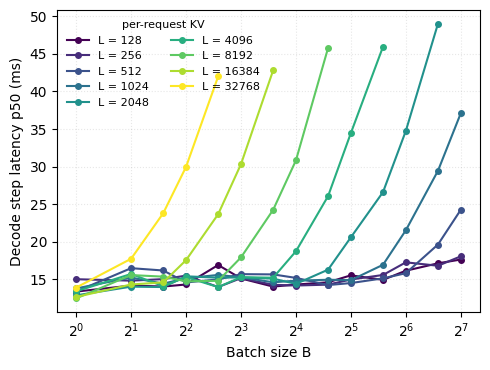

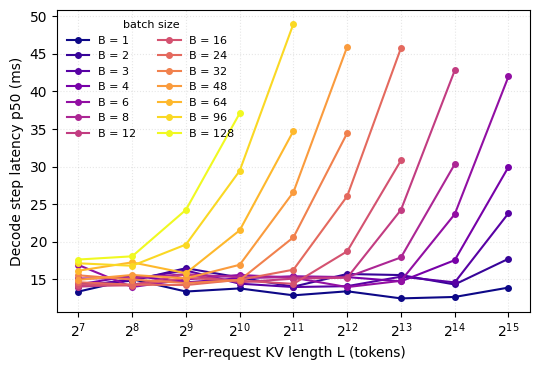

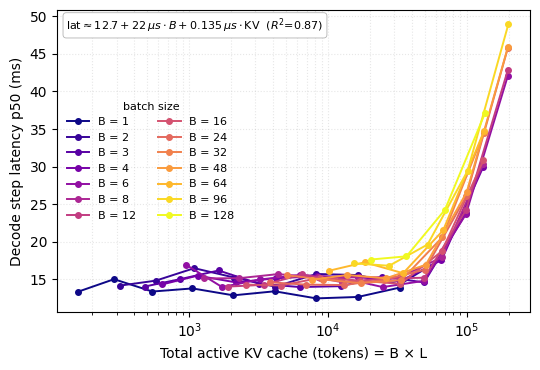

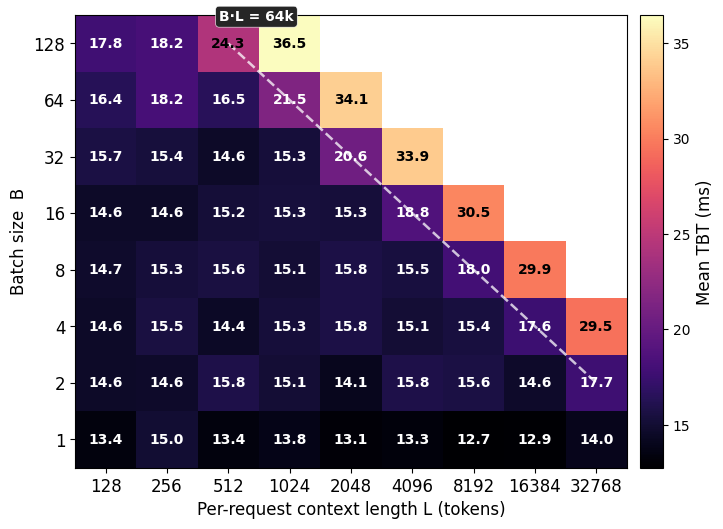

<Figure size 640x480 with 0 Axes>

In [8]:
# Step 2: plot
%matplotlib inline
%run ../scripts/plot_decode_grid.py

In [ ]:
from IPython.display import Image

Image(str(REPO_ROOT / "paper/figures/section3/output/300W/decode_grid_heatmap.png"))